# 📚 Import Required Libraries

This section imports all the essential Python libraries used throughout the project for data manipulation, visualization, and ECG signal processing.

**Libraries Used:**
- **NumPy** – Numerical computations
- **Pandas** – Data loading and preprocessing
- **Matplotlib** – Data visualization
- **OS** – File and directory management
- **Warnings** – Suppress unnecessary warning messages

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# 📂 Load ECG Record

This section loads a sample ECG recording from the **MIT-BIH Arrhythmia Database**. The column names are cleaned to ensure consistent formatting before further preprocessing and heartbeat extraction.

**Objective:**
- Load an ECG recording
- Clean column names
- Prepare the signal for visualization and analysis

Record 100 is used throughout this notebook to demonstrate ECG visualization and annotation processing before extending the workflow to the complete MIT-BIH dataset.

In [6]:
# Load one ECG record

record = 100

ecg = pd.read_csv(f"../dataset/{record}.csv")

# Clean column names
ecg.columns = (
    ecg.columns
    .str.replace("'", "", regex=False)
    .str.strip()
)

print("Shape :", ecg.shape)
print("\nColumns :")
print(ecg.columns.tolist())

ecg.head()

Shape : (650000, 3)

Columns :
['sample #', 'MLII', 'V5']


,sample #,MLII,V5
0,0,995,1011
1,1,995,1011
2,2,995,1011
3,3,995,1011
4,4,995,1011


## 📈 Raw ECG Signal

Visualization of the first **5000 ECG samples**.

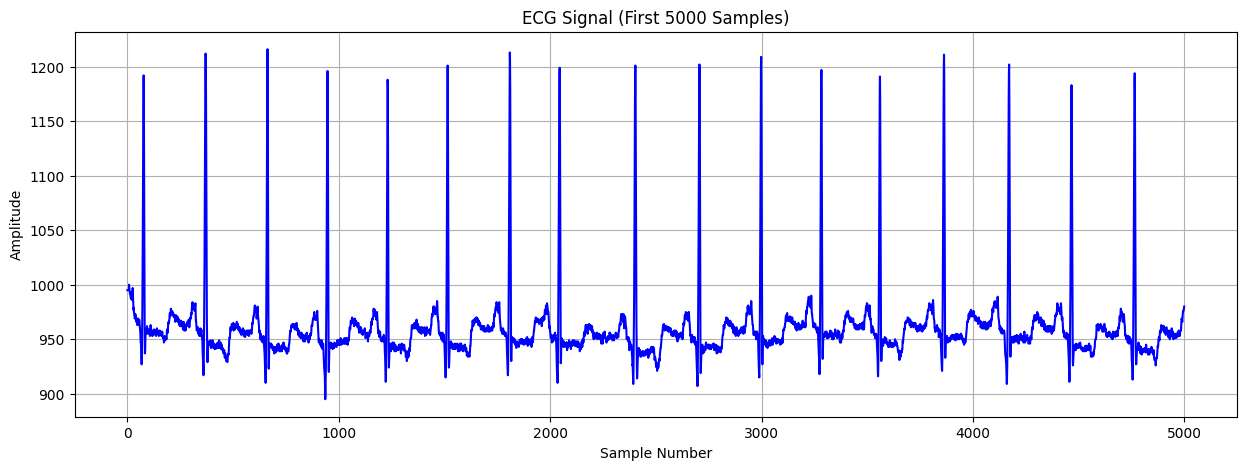

In [7]:
plt.figure(figsize=(15,5))

plt.plot(ecg["MLII"][:5000], color="blue")

plt.title("ECG Signal (First 5000 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

# Load Annotation File

In [ ]:


ann = pd.read_csv(
    "../dataset/100annotations.txt",
    sep=r"\s+",
    header=None,
    skiprows=1,
    engine="python"
)

print("Annotation Shape :", ann.shape)

ann.head()

Annotation Shape : (2274, 7)


,0,1,2,3,4,5,6
0,0:00.050,18,+,0,0,0,(N
1,0:00.214,77,N,0,0,0,None
2,0:01.028,370,N,0,0,0,None
3,0:01.839,662,N,0,0,0,None
4,0:02.628,946,N,0,0,0,None


# Rename Annotation Column

In [ ]:


ann.columns = [
    "Time",
    "Sample",
    "Type",
    "Sub",
    "Chan",
    "Num",
    "Aux"
]

print(ann.columns.tolist())

ann.head()

['Time', 'Sample', 'Type', 'Sub', 'Chan', 'Num', 'Aux']


,Time,Sample,Type,Sub,Chan,Num,Aux
0,0:00.050,18,+,0,0,0,(N
1,0:00.214,77,N,0,0,0,None
2,0:01.028,370,N,0,0,0,None
3,0:01.839,662,N,0,0,0,None
4,0:02.628,946,N,0,0,0,None


# Keep Required Beat Types

In [ ]:


ann = ann[ann["Type"].isin(["N", "A", "V"])]

print("Total Beats :", len(ann))
print()

print(ann["Type"].value_counts())

Total Beats : 2273

Type
N    2239
A      33
V       1
Name: count, dtype: int64


# Function to Process One ECG Record

In [ ]:


def process_record(record):

    # Load ECG
    ecg = pd.read_csv(f"../dataset/{record}.csv")

    ecg.columns = (
        ecg.columns
        .str.replace("'", "", regex=False)
        .str.strip()
    )

    # Select ECG Lead
    if "MLII" in ecg.columns:
        lead = "MLII"
    elif "V5" in ecg.columns:
        lead = "V5"
    else:
        raise ValueError(f"No ECG Lead Found in Record {record}")

    # Load Annotation File
    ann = pd.read_csv(
        f"../dataset/{record}annotations.txt",
        sep=r"\s+",
        header=None,
        skiprows=1,
        engine="python"
    )

    ann = ann.iloc[:, :7]

    ann.columns = [
        "Time",
        "Sample",
        "Type",
        "Sub",
        "Chan",
        "Num",
        "Aux"
    ]

    # Keep only required beat types
    ann = ann[ann["Type"].isin(["N", "A", "V"])]

    X = []
    y = []

    for _, row in ann.iterrows():

        sample = int(row["Sample"])

        # Ignore beats near signal boundaries
        if sample < 100 or sample + 100 >= len(ecg):
            continue

        beat = ecg[lead].iloc[sample-100:sample+100].values

        if len(beat) == 200:
            X.append(beat)
            y.append(row["Type"])

    return np.array(X), np.array(y)

# MIT-BIH Records

In [ ]:


records = [
    100,101,103,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,
    121,122,123,124,

    200,201,202,203,205,207,208,209,
    210,212,213,214,215,217,219,
    220,221,222,223,

    228,230,231,232,233,234
]

print("Total Records :", len(records))

Total Records : 46


# Process All Records

In [ ]:


X_all = []
y_all = []

for record in records:

    print(f"Processing Record {record}...")

    try:
        X, y = process_record(record)

        if len(X) > 0:
            X_all.extend(X)
            y_all.extend(y)

    except Exception as e:
        print(f"Skipped Record {record} -> {e}")

X_all = np.array(X_all)
y_all = np.array(y_all)

print("\nDone!")

Processing Record 100...
Processing Record 101...
Processing Record 103...
Processing Record 105...
Processing Record 106...
Skipped Record 106 -> Expected 6 fields in line 3, saw 7. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.
Processing Record 107...
Processing Record 108...
Processing Record 109...
Processing Record 111...
Processing Record 112...
Processing Record 113...
Processing Record 114...
Processing Record 115...
Processing Record 116...
Processing Record 117...
Processing Record 118...
Processing Record 119...
Processing Record 121...
Processing Record 122...
Processing Record 123...
Processing Record 124...
Processing Record 200...
Processing Record 201...
Processing Record 202...
Processing Record 203...
Processing Record 205...
Processing Record 207...
Processing Record 208...
Processing Record 209...
Processing Record 210...
Processing Record 212...
Processing Record 213...
Processing Record 214...
Processing Record 215...
Pro

# Total heartbeats extracted

In [15]:
print("X_all Shape :", X_all.shape)
print()

print(pd.Series(y_all).value_counts())

X_all Shape : (82408, 200)

N    73259
V     6603
A     2546
Name: count, dtype: int64


# Dataset Information

In [ ]:


print("Dataset Shape :", ecg.shape)
print("\nColumn Names:")
print(ecg.columns.tolist())

print("\nDataset Info:")
ecg.info()

Dataset Shape : (650000, 3)

Column Names:
['sample #', 'MLII', 'V5']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   sample #  650000 non-null  int64
 1   MLII      650000 non-null  int64
 2   V5        650000 non-null  int64
dtypes: int64(3)
memory usage: 14.9 MB


# Random ECG Heartbeats

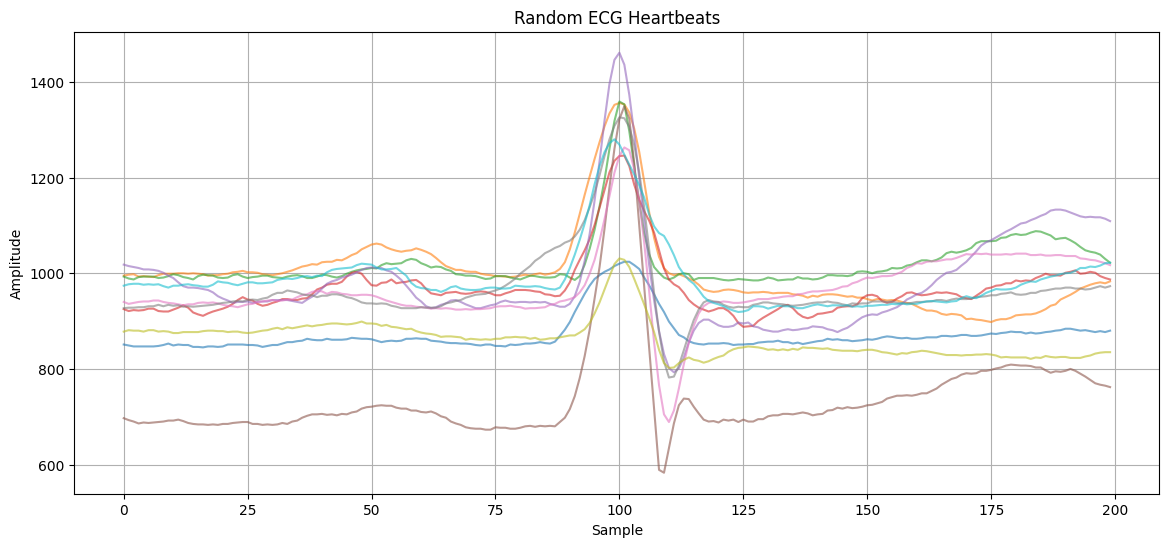

In [30]:
plt.figure(figsize=(14,6))

for i in range(10):
    idx = np.random.randint(0, len(X_all))
    plt.plot(X_all[idx], alpha=0.6)

plt.title("Random ECG Heartbeats")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_all)

print("Classes :", label_encoder.classes_)

Classes : ['A' 'N' 'V']


# Standard Scaling

In [ ]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_all)

print("Scaled Dataset Shape:", X_scaled.shape)

Scaled Dataset Shape: (82408, 200)


## 📏 Feature Scaling

Original vs. standardized ECG heartbeat.

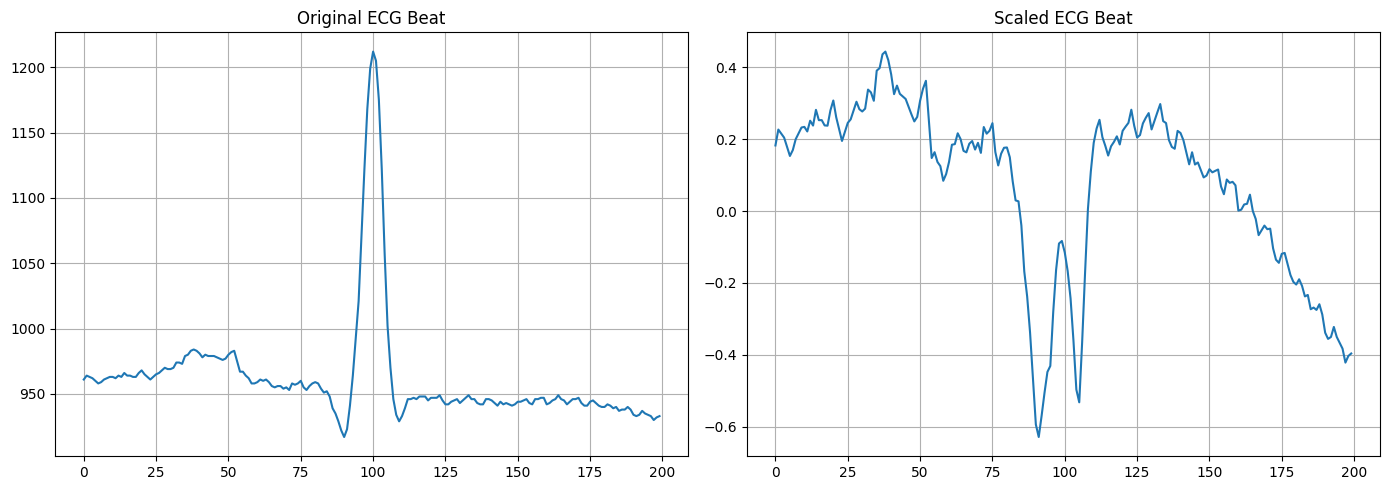

In [49]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(X_all[0])
plt.title("Original ECG Beat")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(X_scaled[0])
plt.title("Scaled ECG Beat")
plt.grid(True)

plt.tight_layout()
plt.show()

# PCA Scatter Plot

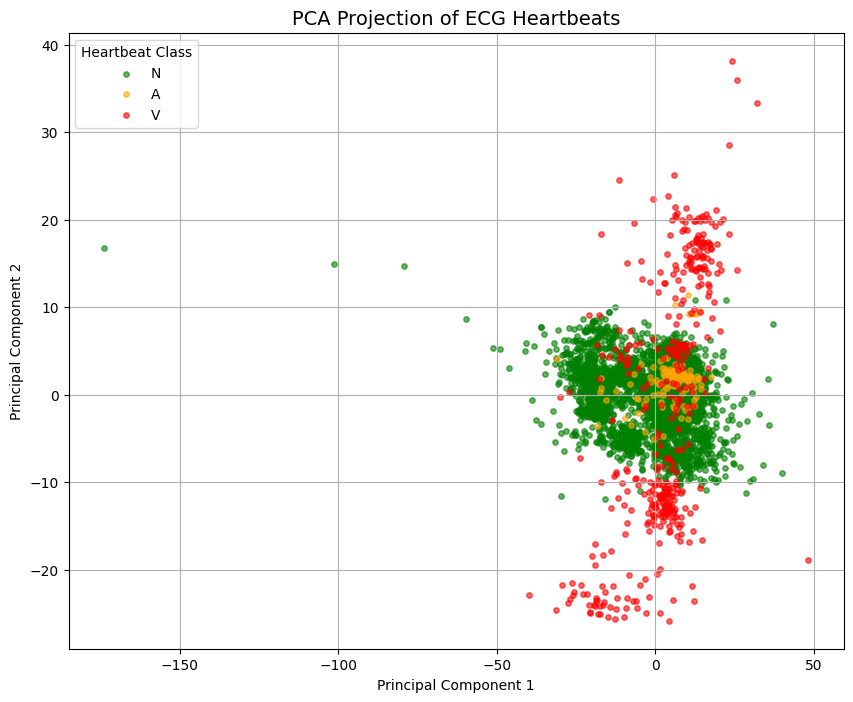

<Figure size 640x480 with 0 Axes>

In [66]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

idx = np.random.choice(len(X_pca), 5000, replace=False)

X_plot = X_pca[idx]
y_plot = y_all[idx]

plt.figure(figsize=(10,8))

colors = {
    "N": "green",
    "A": "orange",
    "V": "red"
}

for cls in ["N", "A", "V"]:
    mask = (y_plot == cls)

    plt.scatter(
        X_plot[mask, 0],
        X_plot[mask, 1],
        s=15,
        alpha=0.6,
        label=cls,
        c=colors[cls]
    )

plt.title("PCA Projection of ECG Heartbeats", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Heartbeat Class")
plt.grid(True)

plt.show()
plt.tight_layout()

plt.savefig(
    "../images/pca_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Variance Explained by Principal Components

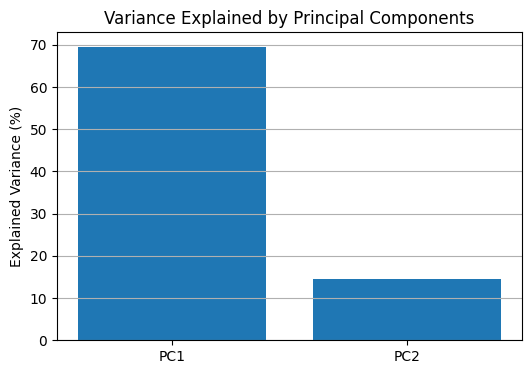

In [53]:
explained = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.bar(
    ["PC1", "PC2"],
    explained * 100
)

plt.ylabel("Explained Variance (%)")
plt.title("Variance Explained by Principal Components")

plt.grid(axis="y")

plt.show()

# Train-Test Split

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (65926, 200)
Testing Shape  : (16482, 200)


# Saving Train-Test Dataset

In [55]:
np.save("../dataset/X_train.npy", X_train)
np.save("../dataset/X_test.npy", X_test)

np.save("../dataset/y_train.npy", y_train)
np.save("../dataset/y_test.npy", y_test)

print("✅ Dataset Saved Successfully")

✅ Dataset Saved Successfully


# Representation of ECG Heartbeats by Class

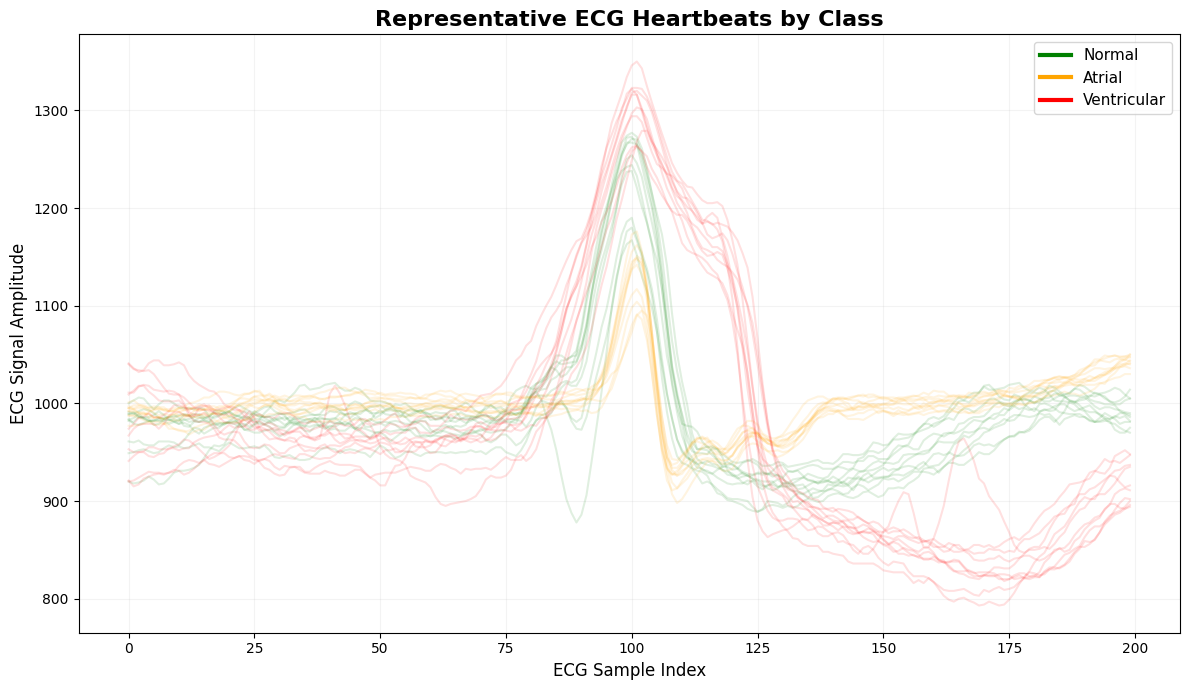

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(12,7))

colors = {
    "N": "green",
    "A": "orange",
    "V": "red"
}

labels = {
    "N": "Normal",
    "A": "Atrial",
    "V": "Ventricular"
}

for cls in ["N", "A", "V"]:

    idx = np.where(y_all == cls)[0]

    # First 10 representative beats
    center = len(idx) // 2
    idx = idx[center:center+10]

    for i in idx:

        plt.plot(
            X_all[i],
            color=colors[cls],
            alpha=0.12,
            linewidth=1.5
        )

legend = [
    Line2D([0], [0], color="green", lw=3, label="Normal"),
    Line2D([0], [0], color="orange", lw=3, label="Atrial"),
    Line2D([0], [0], color="red", lw=3, label="Ventricular")
]

plt.legend(handles=legend, fontsize=11)

plt.title(
    "Representative ECG Heartbeats by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("ECG Sample Index", fontsize=12)

plt.ylabel("ECG Signal Amplitude", fontsize=12)

plt.grid(alpha=0.15)

plt.tight_layout()

plt.savefig(
    "../images/ecg_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Average Heartbeat Comparison

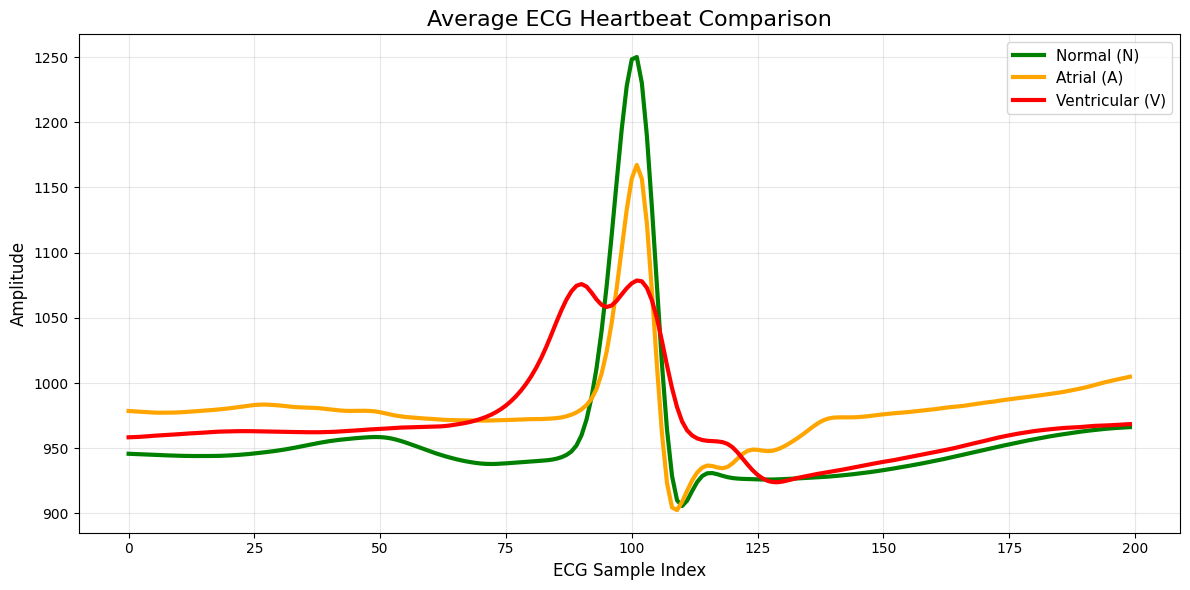

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

# Calculate Mean ECG Beat of Each Class
normal_mean = X_all[y_all == "N"].mean(axis=0)
atrial_mean = X_all[y_all == "A"].mean(axis=0)
ventricular_mean = X_all[y_all == "V"].mean(axis=0)

# Plot
plt.figure(figsize=(12,6))

plt.plot(normal_mean,
         color="green",
         linewidth=3,
         label="Normal (N)")

plt.plot(atrial_mean,
         color="orange",
         linewidth=3,
         label="Atrial (A)")

plt.plot(ventricular_mean,
         color="red",
         linewidth=3,
         label="Ventricular (V)")

plt.title("Average ECG Heartbeat Comparison", fontsize=16)

plt.xlabel("ECG Sample Index", fontsize=12)

plt.ylabel("Amplitude", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

plt.tight_layout()

plt.savefig("../images/average_heartbeat_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Class Distribution

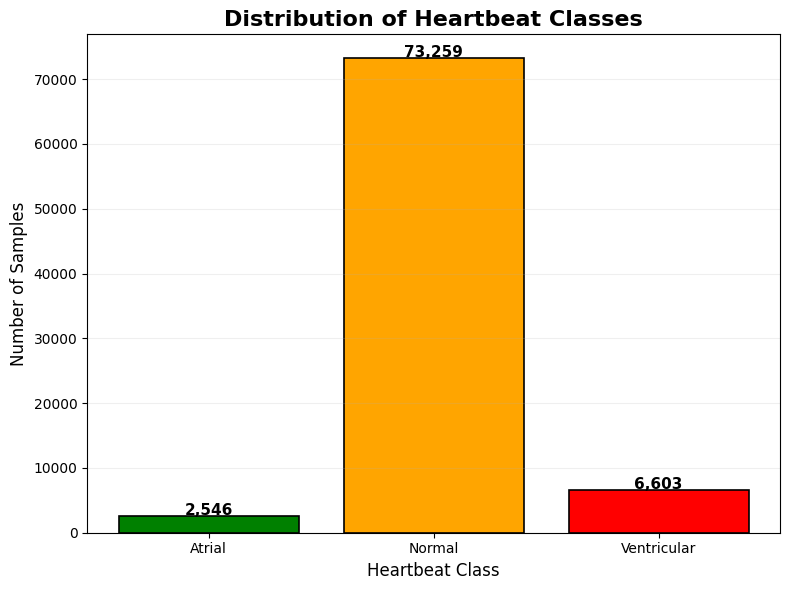

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

# Count Samples
classes, counts = np.unique(y_all, return_counts=True)

# Rename Labels
label_map = {
    "N": "Normal",
    "A": "Atrial",
    "V": "Ventricular"
}

labels = [label_map[c] for c in classes]

colors = ["green", "orange", "red"]

plt.figure(figsize=(8,6))

bars = plt.bar(
    labels,
    counts,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# Add Count Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 200,
        f"{height:,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Distribution of Heartbeat Classes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Heartbeat Class", fontsize=12)

plt.ylabel("Number of Samples", fontsize=12)

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()